##        BIG BASKET EDA PROJECT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("BigBasket Products.csv")

In [3]:
df.head(12)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...
5,6,Germ - Removal Multipurpose Wipes,Cleaning & Household,All Purpose Cleaners,Nature Protect,169.0,199.0,Disinfectant Spray & Cleaners,3.3,Stay protected from contamination with Multipu...
6,7,Multani Mati,Beauty & Hygiene,Skin Care,Satinance,58.0,58.0,Face Care,3.6,Satinance multani matti is an excellent skin t...
7,8,Hand Sanitizer - 70% Alcohol Base,Beauty & Hygiene,Bath & Hand Wash,Bionova,250.0,250.0,Hand Wash & Sanitizers,4.0,70%Alcohol based is gentle of hand leaves skin...
8,9,Biotin & Collagen Volumizing Hair Shampoo + Bi...,Beauty & Hygiene,Hair Care,StBotanica,1098.0,1098.0,Shampoo & Conditioner,3.5,"An exclusive blend with Vitamin B7 Biotin, Hyd..."
9,10,"Scrub Pad - Anti- Bacterial, Regular",Cleaning & Household,"Mops, Brushes & Scrubs",Scotch brite,20.0,20.0,"Utensil Scrub-Pad, Glove",4.3,Scotch Brite Anti- Bacterial Scrub Pad thoroug...


In [4]:
df.describe()

,index,sale_price,market_price,rating
count,27555.00000,27549.000000,27555.000000,18919.000000
mean,13778.00000,334.648391,382.056664,3.943295
std,7954.58767,1202.102113,581.730717,0.739217
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.320000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,112475.000000,12500.000000,5.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  str    
 2   category      27555 non-null  str    
 3   sub_category  27555 non-null  str    
 4   brand         27554 non-null  str    
 5   sale_price    27549 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  str    
 8   rating        18919 non-null  float64
 9   description   27440 non-null  str    
dtypes: float64(3), int64(1), str(6)
memory usage: 2.1 MB


In [6]:
df.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         6
market_price       0
type               0
rating          8636
description      115
dtype: int64

The dataset contains missing values, with the rating column having around 8636 null values and the description column having 115 null values. This indicates incomplete customer feedback and minor gaps in product information.

The rating column contained a large number of missing values (~8000). Since ratings are important for analysis and cannot be ignored, the missing values were replaced using the median value to avoid the impact of extreme values.

In [8]:
df.fillna({'rating': df['rating'].median()}, inplace=True)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.00,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.00,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.00,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.00,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.00,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...
...,...,...,...,...,...,...,...,...,...,...
27550,27551,"Wottagirl! Perfume Spray - Heaven, Classic",Beauty & Hygiene,Fragrances & Deos,Layerr,199.20,249.0,Perfume,3.9,Layerr brings you Wottagirl Classic fragrant b...
27551,27552,Rosemary,Gourmet & World Food,Cooking & Baking Needs,Puramate,67.50,75.0,"Herbs, Seasonings & Rubs",4.0,Puramate rosemary is enough to transform a dis...
27552,27553,Peri-Peri Sweet Potato Chips,Gourmet & World Food,"Snacks, Dry Fruits, Nuts",FabBox,200.00,200.0,Nachos & Chips,3.8,We have taken the richness of Sweet Potatoes (...
27553,27554,Green Tea - Pure Original,Beverages,Tea,Tetley,396.00,495.0,Tea Bags,4.2,"Tetley Green Tea with its refreshing pure, ori..."


In [9]:
df.drop('description', axis=1, inplace=True)

In [10]:
df.isnull().sum()

index           0
product         1
category        0
sub_category    0
brand           1
sale_price      6
market_price    0
type            0
rating          0
dtype: int64

In [11]:
df['product'] = df['product'].fillna("Unknown Product")

In [13]:
df['brand'] = df['brand'].fillna(df['brand'].mode()[0])

In [15]:
df['sale_price'] = df['sale_price'].fillna(df['sale_price'].median())

In [16]:
df.isnull().sum()

index           0
product         0
category        0
sub_category    0
brand           0
sale_price      0
market_price    0
type            0
rating          0
dtype: int64

* TOP Selling product

In [17]:
df['product'].value_counts().head(10)

product
Turmeric Powder/Arisina Pudi          26
Extra Virgin Olive Oil                15
Cow Ghee/Tuppa                        14
Olive Oil - Extra Virgin              12
Soft Drink                            12
Colorsilk Hair Colour With Keratin    12
Coriander Powder                      11
Powder - Coriander                    11
Ghee/Tuppa                            11
Hand Sanitizer                        10
Name: count, dtype: int64

* Least Selling Product

In [18]:
df['product'].value_counts().tail(10)

product
Acidshoonya Tablet                                 1
Herbal Rose & Apricot Walnut Facial Scrub          1
Embellish Skin Lightening Serum                    1
Popcorn - French Butter & Pink Salt                1
Brass Dhoop Aarti With Wooden Handle,No.3          1
Toilet Cleaning Brush - Round With Holder (Big)    1
Organic Powder - Garam Masala                      1
Wottagirl! Perfume Spray - Heaven, Classic         1
Peri-Peri Sweet Potato Chips                       1
Green Tea - Pure Original                          1
Name: count, dtype: int64

Added a new column --> Discount

In [19]:
df['discount'] = df['market_price'] - df['sale_price']

In [21]:
df['discount_percent'] = (df['discount'] / df['market_price']) * 100

In [22]:
df.head(5)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,discount,discount_percent
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,0.0,0.000000
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,0.0,0.000000
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,131.0,52.400000
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,27.0,15.340909
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,0.0,0.000000


* Handling Outliers

In [24]:
Q1 = df['sale_price'].quantile(0.25)
Q3 = df['sale_price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [25]:
mean_val = df['sale_price'].mean()

df['sale_price'] = df['sale_price'].apply(
    lambda x: mean_val if x < lower or x > upper else x
)

# Visualization 

# Top Categories

C:\Users\ExpertBook\AppData\Local\Temp\ipykernel_11248\3168184981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='coolwarm')


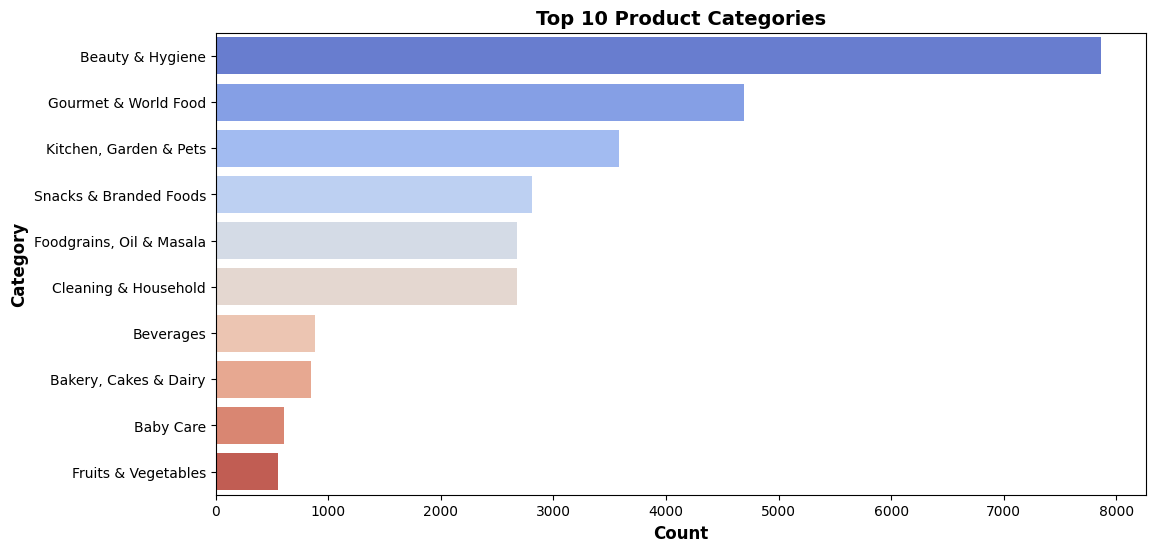

In [31]:
plt.figure(figsize=(12,6))
top_categories = df['category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='coolwarm')

plt.title("Top 10 Product Categories", fontsize=14, fontweight='bold')
plt.xlabel("Count", fontsize=12, fontweight='bold')
plt.ylabel("Category",fontsize=12, fontweight='bold')

plt.show()

# Sale Price Distribution

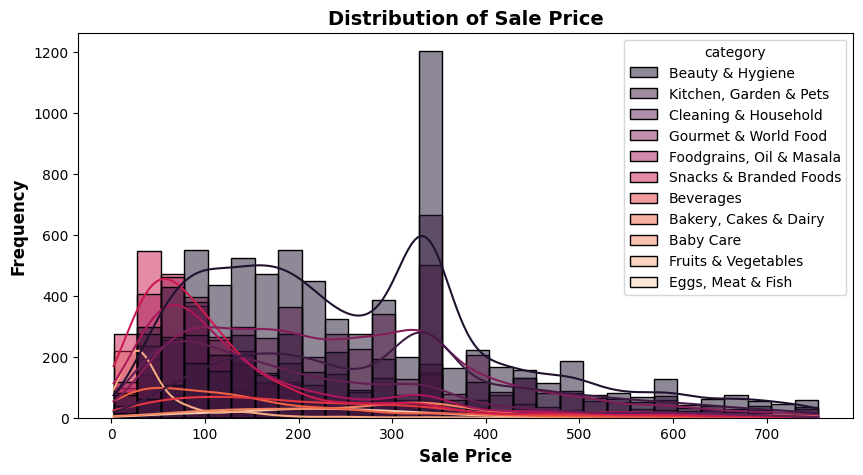

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(data=df,x='sale_price', bins=30, kde=True, hue='category',palette='rocket')

plt.title("Distribution of Sale Price",fontsize=14, fontweight='bold')
plt.xlabel("Sale Price",fontsize=12, fontweight='bold')
plt.ylabel("Frequency",fontsize=12, fontweight='bold')

plt.show()

# Rating Distribution

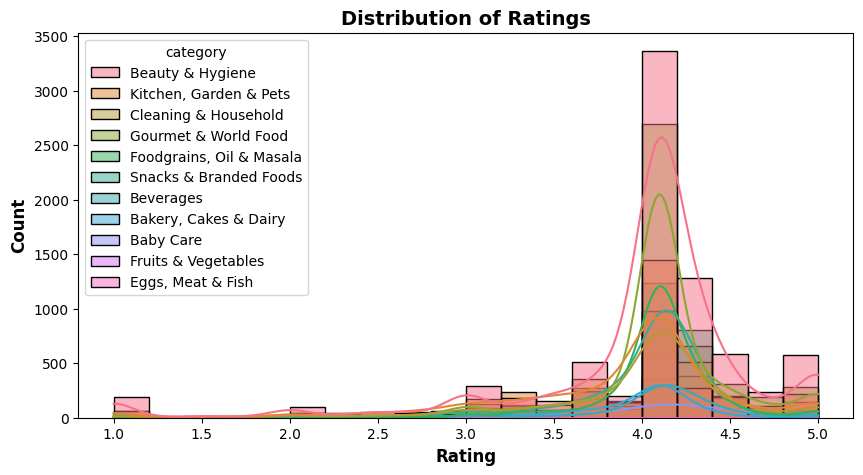

In [42]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='rating', bins=20, kde=True, hue='category', palette='husl' )

plt.title("Distribution of Ratings",fontsize=14, fontweight='bold')
plt.xlabel("Rating",fontsize=12, fontweight='bold')
plt.ylabel("Count",fontsize=12, fontweight='bold')

plt.show()

# Top Brands 

C:\Users\ExpertBook\AppData\Local\Temp\ipykernel_11248\3537183084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index,palette='mako')


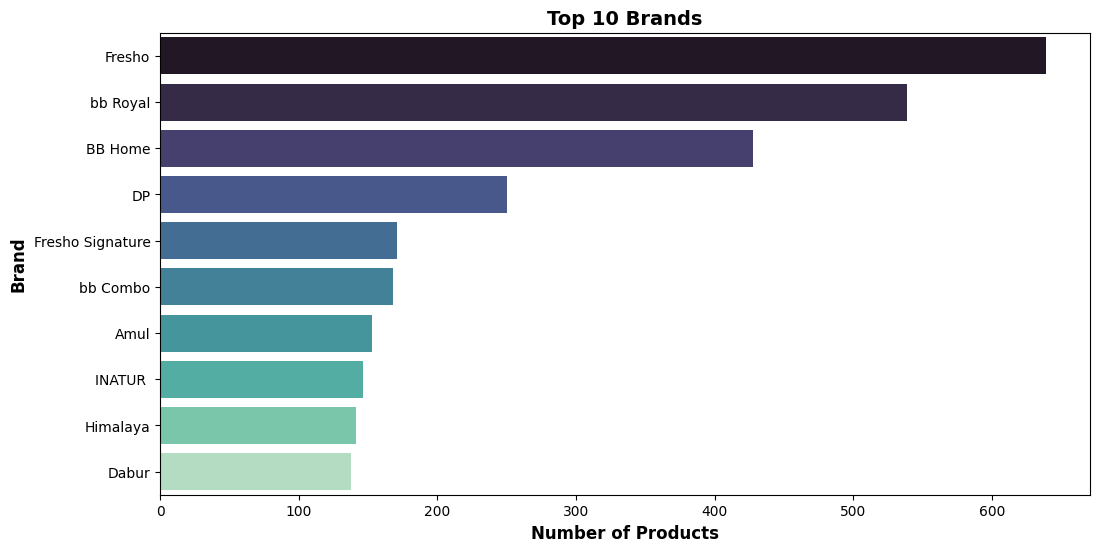

In [48]:
plt.figure(figsize=(12,6))
top_brands = df['brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index,palette='mako')

plt.title("Top 10 Brands",fontsize=14, fontweight='bold')
plt.xlabel("Number of Products",fontsize=12, fontweight='bold')
plt.ylabel("Brand",fontsize=12, fontweight='bold')

plt.show()

# Conclusion

This analysis of the BigBasket dataset provided insights into product pricing, discount strategies, and customer preferences. It was observed that certain categories dominate the platform, while pricing and discounts significantly influence product ratings. Handling missing values and outliers improved data quality, enabling more reliable insights. Overall, this project demonstrates the importance of data cleaning and visualization in extracting meaningful business insights from raw data.